In [1]:
from esda.moran import Moran
import numpy as np
import libpysal.weights.set_operations as Wsets
from libpysal.weights import Queen, KNN
import seaborn as sns
import geopandas as gpd
import contextily as cx
from sklearn import cluster
from sklearn.cluster import KMeans, AgglomerativeClustering
from libpysal import weights
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram,linkage
import pandas as pd

c:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\entorno\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
gdf = gpd.read_file(r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Poligonos\Poligonos\Municipios_Antioquia.shp")
#gdf = gpd.read_file(r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Poligonos\Poligonos\Subzonas_Antioquia.shp")
#gdf = gpd.read_file(r"C:\Analisis_Geoespacial\2026_I_Analisis_Geoespacial\Data\Poligonos\Poligonos\Subzonas_Extension_Antioquia.shp")
print(gdf.crs)
gdf["Gradiente"]=gdf["Elev_max"]-gdf["Elev_min"]
gdf_ON = gdf.to_crs(epsg=9377)
gdf.head()

EPSG:4326


,OBJECTID_1,NOMBRE_ENT,CATEGORIA,DEPARTAMEN,COD_DEPART,COD_MUNICI,AREA_KM,OBSERVACIO,PK_CUE,ACTO_ADMIN,...,TPI_std,TPI_cv,Curv_std,Curv_cv,Pend_std,Pend_cv,Elev_std,Elev_cv,geometry,Gradiente
0,4267.0,YARUMAL,M,ANTIOQUIA,05,887,717.285352,NaN,NaN,None,...,2.504917,1302.269109,0.985391,1649.239133,18.299343,0.553453,571.171727,0.270422,"POLYGON ((-75.31983 7.24079, -75.31946 7.24077...",2436.510071
1,4306.0,ANGOSTURA,M,ANTIOQUIA,05,038,329.457055,NaN,NaN,None,...,2.422017,1071.740520,0.926558,1166.526582,13.356039,0.472276,407.187806,0.199472,"POLYGON ((-75.26615 6.96567, -75.26514 6.96303...",1618.769897
2,4536.0,NARIÑO,M,ANTIOQUIA,05,483,314.940324,NaN,501785.0,None,...,3.471513,-155.312073,1.353369,-192.803303,22.404906,0.420936,614.566000,0.384461,"POLYGON ((-75.23043 5.67613, -75.22987 5.67602...",2885.710022
3,4571.0,CARAMANTA,M,ANTIOQUIA,05,145,90.521818,NaN,501752.0,None,...,3.015808,380.332995,1.181636,426.117632,19.547508,0.417466,591.767063,0.331119,"POLYGON ((-75.58067 5.60548, -75.58068 5.60545...",2501.120056
4,4579.0,SANTA ROSA DE OSOS,M,ANTIOQUIA,05,686,861.242001,NaN,502270.0,None,...,2.248501,-1334.154124,0.853320,-1660.639540,12.810342,0.550760,338.358861,0.139148,"POLYGON ((-75.5764 6.87091, -75.57589 6.86958,...",1885.729980


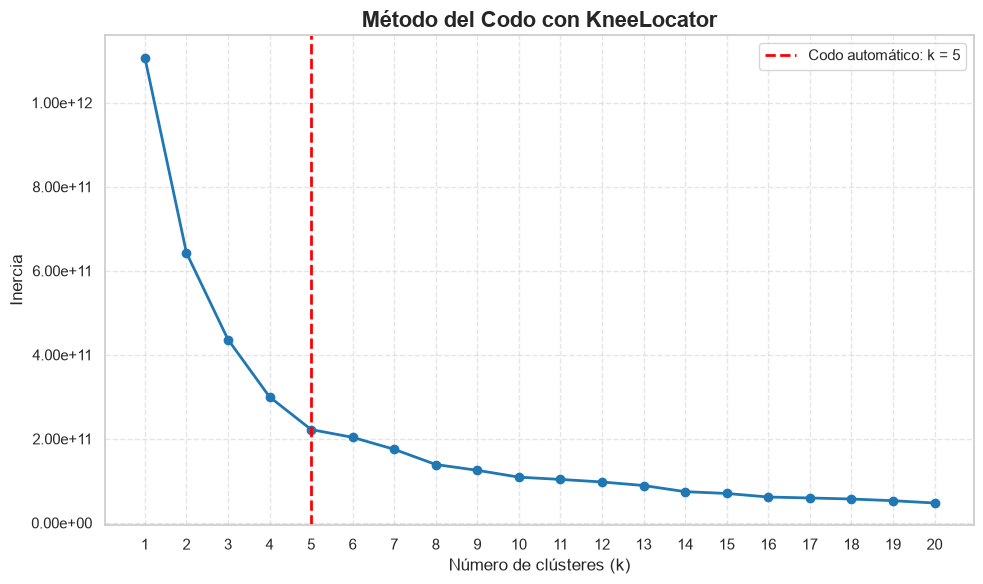

k óptimo según KneeLocator: 5


In [14]:
if gdf.crs.is_geographic:
    gdf_proyectado = gdf.to_crs(gdf.estimate_utm_crs())
else:
    gdf_proyectado = gdf.copy()

# Centroides de cada polígono
coordenadas = np.column_stack((
    gdf_proyectado.geometry.centroid.x,
    gdf_proyectado.geometry.centroid.y
))

from sklearn.cluster import KMeans
from kneed import KneeLocator
import matplotlib.pyplot as plt
import numpy as np

coordenadas = np.column_stack((
    gdf_ON.geometry.centroid.x,
    gdf_ON.geometry.centroid.y
))

def elbow_kneelocator(datos, max_clusters=20):

    inercias = []
    k_values = range(1, max_clusters + 1)

    for k in k_values:
        kmeans = KMeans(
            n_clusters=k,
            n_init="auto",
            random_state=42
        )
        kmeans.fit(datos)
        inercias.append(kmeans.inertia_)

    knee = KneeLocator(
        list(k_values),
        inercias,
        curve="convex",
        direction="decreasing"
    )

    k_optimo = knee.knee

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(
        k_values,
        inercias,
        marker="o",
        linewidth=2,
        color="#1f77b4"
    )

    if k_optimo is not None:
        ax.axvline(
            k_optimo,
            color="red",
            linestyle="--",
            linewidth=2,
            label=f"Codo automático: k = {k_optimo}"
        )

    ax.set_title("Método del Codo con KneeLocator", fontsize=16, fontweight="bold")
    ax.set_xlabel("Número de clústeres (k)")
    ax.set_ylabel("Inercia")
    ax.set_xticks(list(k_values))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,.2e}".format(x)))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()

    plt.tight_layout()
    plt.show()

    print("k óptimo según KneeLocator:", k_optimo)

    return k_optimo, inercias

k_optimo, inercias = elbow_kneelocator(coordenadas, max_clusters=20)

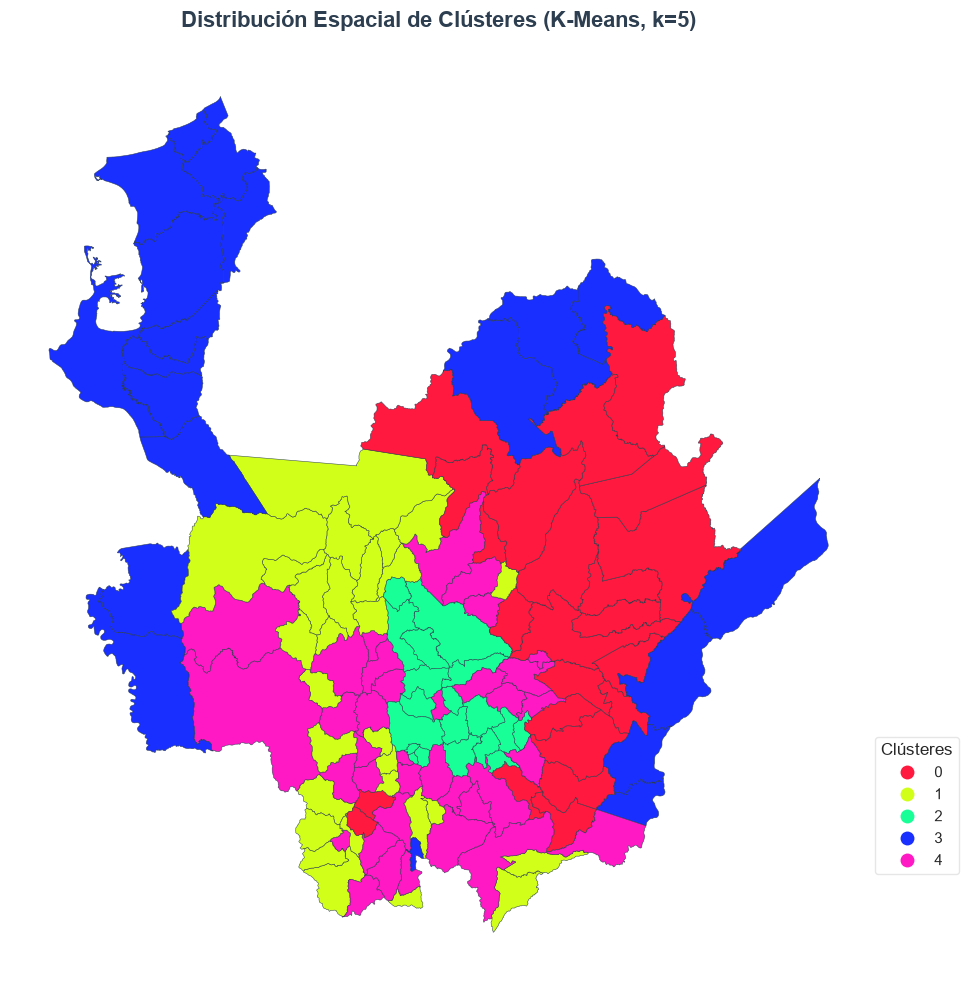


  ANÁLISIS ESTADÍSTICO DE CLÚSTERES

■ VALORES PROMEDIO ORIGINALES POR CLÚSTER:


,Pend_mean,LAI_mean,Elev_mean
KMeans_5,,,
0,31.92,3.60,908.69
1,52.05,3.21,1701.71
2,24.34,2.06,2191.44
3,13.92,2.34,205.85
4,36.17,2.77,1673.31



■ VALORES ESTANDARIZADOS (Z-SCORE) POR CLÚSTER:
*(Permite comparar variables con diferentes escalas: >0 alto, <0 bajo)*


,Pend_mean,LAI_mean,Elev_mean
cluster,,,
0,-0.14,1.16,-0.69
1,1.32,0.55,0.43
2,-0.69,-1.22,1.12
3,-1.45,-0.80,-1.68
4,0.17,-0.12,0.39



──────────────────────────────────────────────────
 RESUMEN DE COMPORTAMIENTO
──────────────────────────────────────────────────

👉 Clúster 0:
   ⚪ Pend_mean (Neutro: 31.9) | 🟢 LAI_mean (Muy Alto: 3.6) | 🟧 Elev_mean (Bajo: 908.7)

👉 Clúster 1:
   🟢 Pend_mean (Muy Alto: 52.0) | 🟩 LAI_mean (Alto: 3.2) | 🟩 Elev_mean (Alto: 1701.7)

👉 Clúster 2:
   🟧 Pend_mean (Bajo: 24.3) | 🔴 LAI_mean (Muy Bajo: 2.1) | 🟢 Elev_mean (Muy Alto: 2191.4)

👉 Clúster 3:
   🔴 Pend_mean (Muy Bajo: 13.9) | 🟧 LAI_mean (Bajo: 2.3) | 🔴 Elev_mean (Muy Bajo: 205.8)

👉 Clúster 4:
   ⚪ Pend_mean (Neutro: 36.2) | ⚪ LAI_mean (Neutro: 2.8) | ⚪ Elev_mean (Neutro: 1673.3)


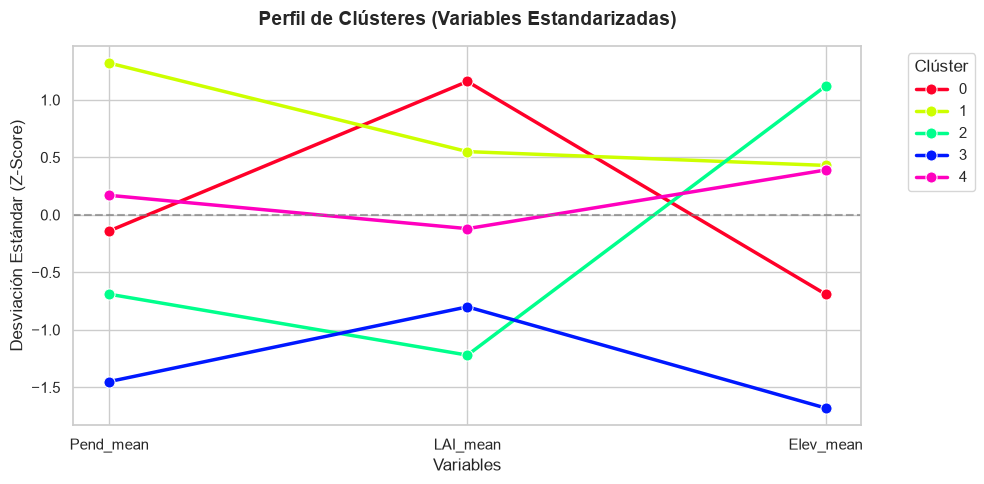

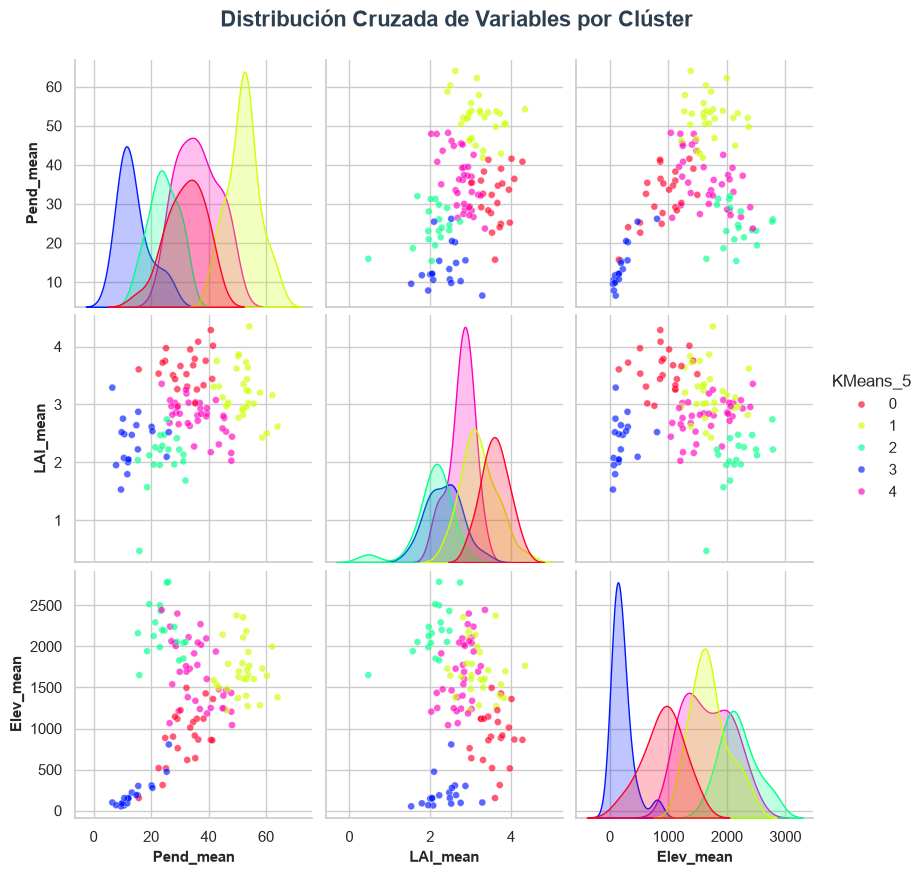

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# --- CONFIGURACIÓN DE ESTILO GLOBAL ---
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["figure.facecolor"] = "white"

# Elegimos una paleta de colores limpia y distinguible para los clústeres
PALETA_CLUSTERS = "gist_rainbow"  # Opciones excelentes: "Set2", "tab10", "colorblind"


def kmeans_plot(gdf, variables, k=5):
    # Estandarización y clustering
    X = StandardScaler().fit_transform(gdf[variables])
    cluster_col = f"KMeans_{k}"
    
    gdf[cluster_col] = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    ).fit_predict(X)

    # Gráfico del mapa espacial
    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Dibujamos el mapa con estilo minimalista
    gdf.plot(
        column=cluster_col,
        categorical=True,
        cmap=PALETA_CLUSTERS,
        legend=True,
        linewidth=0.4,
        edgecolor="#2c3e50", # Un gris oscuro/azul para definir fronteras limpias
        alpha=0.9,
        legend_kwds={
            "title": "Clústeres",
            "loc": "lower left",
            "bbox_to_anchor": (1, 0.1),
            "frameon": True,
            "shadow": False,
            "facecolor": "white",
            "edgecolor": "#e0e0e0"
        },
        ax=ax
    )

    # Título limpio y sin bordes de ejes
    ax.set_title(
        f"Distribución Espacial de Clústeres (K-Means, k={k})", 
        fontsize=16, 
        fontweight="bold", 
        pad=20,
        color="#2c3e50"
    )
    ax.set_axis_off()
    
    plt.tight_layout()
    plt.show()

    return gdf


def describir_clusters_estilizado(gdf, variables, columna_cluster):
    # 1. Resumen con valores originales
    resumen = gdf.groupby(columna_cluster)[variables].mean().round(2)

    # 2. Resumen estandarizado (Z-score)
    X_std = pd.DataFrame(
        StandardScaler().fit_transform(gdf[variables]),
        columns=variables,
        index=gdf.index
    )

    resumen_std = (
        X_std
        .assign(cluster=gdf[columna_cluster])
        .groupby("cluster")
        .mean()
        .round(2)
    )

    # --- SALIDA VISUALMENTE ATRACTIVA EN JUPYTER ---
    print("\n" + "="*50)
    print("  ANÁLISIS ESTADÍSTICO DE CLÚSTERES")
    print("="*50 + "\n")

    # Estilizamos el dataframe con un gradiente de color (Rojo para bajo, Verde para alto)
    print("■ VALORES PROMEDIO ORIGINALES POR CLÚSTER:")
    display(resumen.style.background_gradient(cmap="RdYlGn", axis=0).format("{:.2f}"))

    print("\n■ VALORES ESTANDARIZADOS (Z-SCORE) POR CLÚSTER:")
    print("*(Permite comparar variables con diferentes escalas: >0 alto, <0 bajo)*")
    display(resumen_std.style.background_gradient(cmap="coolwarm", axis=0, vmin=-1.5, vmax=1.5).format("{:.2f}"))

    # 3. Interpretación automática simplificada
    print("\n" + "─"*50)
    print(" RESUMEN DE COMPORTAMIENTO")
    print("─"*50)
    
    for c in resumen_std.index:
        perfil = []
        for var in variables:
            z = resumen_std.loc[c, var]
            if z >= 1.0:
                perfil.append(f"🟢 {var} (Muy Alto: {resumen.loc[c,var]:.1f})")
            elif z >= 0.4:
                perfil.append(f"🟩 {var} (Alto: {resumen.loc[c,var]:.1f})")
            elif z <= -1.0:
                perfil.append(f"🔴 {var} (Muy Bajo: {resumen.loc[c,var]:.1f})")
            elif z <= -0.4:
                perfil.append(f"🟧 {var} (Bajo: {resumen.loc[c,var]:.1f})")
            else:
                perfil.append(f"⚪ {var} (Neutro: {resumen.loc[c,var]:.1f})")
                
        print(f"\n👉 Clúster {c}:")
        print("   " + " | ".join(perfil))

    # --- NUEVO GRÁFICO: Perfil medio de los clústeres ---
    plt.figure(figsize=(10, 5))
    
    # SOLUCIÓN AL ERROR: Reseteamos el índice y usamos el nombre real de la columna resultante ("cluster")
    resumen_std_flat = resumen_std.reset_index()
    resumen_std_melted = resumen_std_flat.melt(id_vars="cluster")
    
    sns.lineplot(
        data=resumen_std_melted, 
        x="variable", 
        y="value", 
        hue="cluster",  # Usamos "cluster" de forma fija ya que el groupby lo nombró así
        palette=PALETA_CLUSTERS,
        marker="o", 
        linewidth=2.5,
        markersize=8
    )
    
    plt.axhline(0, color="gray", linestyle="--", alpha=0.7)
    plt.title("Perfil de Clústeres (Variables Estandarizadas)", fontsize=14, fontweight="bold", pad=15)
    plt.ylabel("Desviación Estándar (Z-Score)")
    plt.xlabel("Variables")
    plt.legend(title="Clúster", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

    return resumen, resumen_std


# --- EJECUCIÓN ---

# 1. Definición de variables y clustering
variables = ["Pend_mean", "LAI_mean", "Elev_mean"]
gdf = kmeans_plot(gdf, variables, k=5)

# 2. Análisis e interpretación de tablas
resumen, resumen_std = describir_clusters_estilizado(gdf, variables, "KMeans_5")

# 3. Pairplot estéticamente mejorado
g = sns.pairplot(
    gdf,
    vars=variables,
    hue="KMeans_5",
    palette=PALETA_CLUSTERS,
    diag_kind="kde",
    height=2.8,
    plot_kws={
        "s": 25,          # Puntos ligeramente más pequeños para evitar solapamiento masivo
        "alpha": 0.65,      # Transparencia más suave
        "edgecolor": "white",
        "linewidth": 0.3
    },
    diag_kws={
        "fill": True,
        "alpha": 0.25      # Curvas de densidad más suaves para no tapar la rejilla
    }
)

# Ajuste fino del diseño del pairplot
g.fig.suptitle(
    "Distribución Cruzada de Variables por Clúster",
    y=1.04,
    fontsize=16,
    fontweight="bold",
    color="#2c3e50"
)

# Mejoramos la estética de las etiquetas de los ejes
for ax in g.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=11, fontweight="semibold")
        ax.set_ylabel(ax.get_ylabel(), fontsize=11, fontweight="semibold")

plt.show()

In [28]:
w = weights.Queen.from_dataframe(gdf, idVariable='COD_MUNICI')
w.transform = 'R'
gdf['w_Tot_event'] = weights.lag_spatial(w, gdf['Tot_event'])
gdf['w_Pend_mean'] = weights.lag_spatial(w, gdf['Pend_mean'])
gdf['w_LAI_mean'] = weights.lag_spatial(w, gdf['LAI_mean'])
gdf['w_Curv_mean'] = weights.lag_spatial(w, gdf['Curv_mean'])
gdf['w_TRI_mean'] = weights.lag_spatial(w, gdf['TRI_mean'])
gdf['w_TPI_mean'] = weights.lag_spatial(w, gdf['TPI_mean'])

C:\Users\juand\AppData\Local\Temp\ipykernel_22748\3776050619.py:1: FutureWarning: `idVariable` is deprecated and will be removed in future. Use `ids` instead.
  w = weights.Queen.from_dataframe(gdf, idVariable='COD_MUNICI')


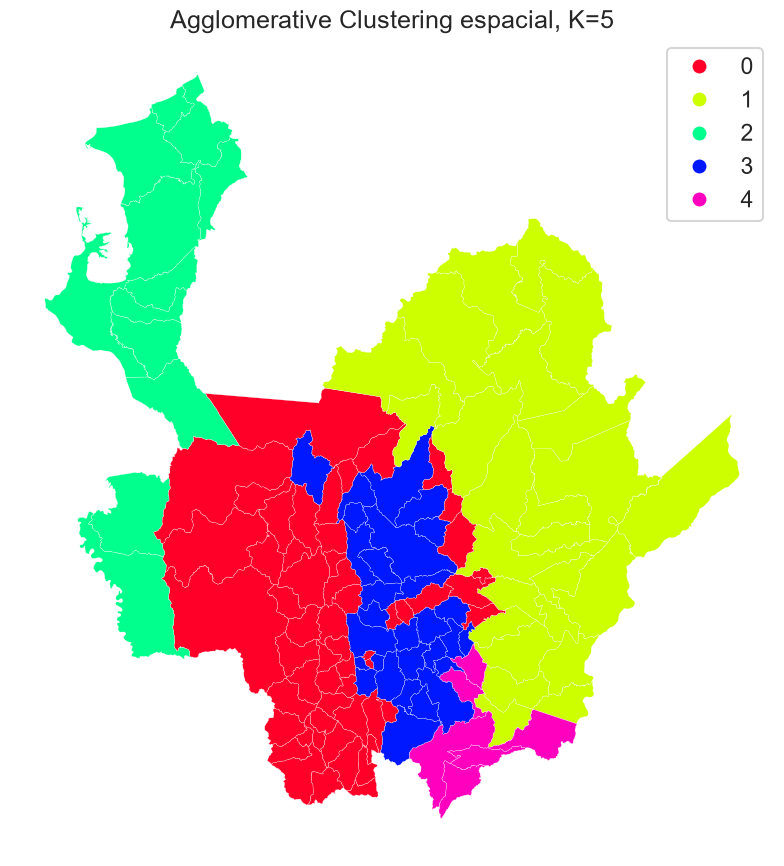

VALORES PROMEDIO POR CLÚSTER


,Pend_mean,LAI_mean,Elev_mean
sagg5cls,,,
0,43.57,2.90,1555.04
1,25.43,3.34,626.34
2,13.61,2.12,166.05
3,29.12,2.53,2201.94
4,42.02,3.42,1499.03




VALORES ESTANDARIZADOS (z-score)


,Pend_mean,LAI_mean,Elev_mean
cluster,,,
0,0.70,0.07,0.23
1,-0.61,0.76,-1.08
2,-1.47,-1.13,-1.73
3,-0.35,-0.50,1.14
4,0.59,0.88,0.15




INTERPRETACIÓN

CLÚSTER 0
Pend_mean      : Alto       (43.57)
LAI_mean       : Medio      (2.90)
Elev_mean      : Medio      (1555.04)

CLÚSTER 1
Pend_mean      : Bajo       (25.43)
LAI_mean       : Alto       (3.34)
Elev_mean      : Muy bajo   (626.34)

CLÚSTER 2
Pend_mean      : Muy bajo   (13.61)
LAI_mean       : Muy bajo   (2.12)
Elev_mean      : Muy bajo   (166.05)

CLÚSTER 3
Pend_mean      : Medio      (29.12)
LAI_mean       : Bajo       (2.53)
Elev_mean      : Muy alto   (2201.94)

CLÚSTER 4
Pend_mean      : Alto       (42.02)
LAI_mean       : Alto       (3.42)
Elev_mean      : Medio      (1499.03)


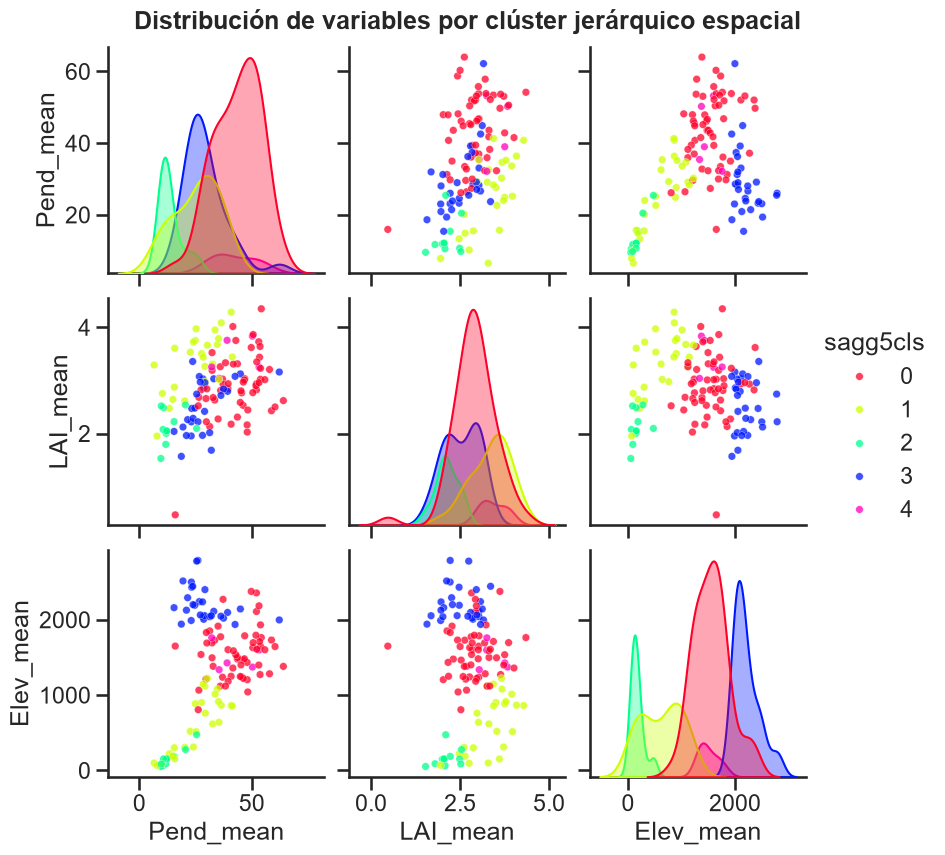

In [42]:
from sklearn import cluster
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# ==========================
# Clustering jerárquico espacial
# ==========================
w = KNN.from_dataframe(gdf, k=5)
np.random.seed(123456)
sagg5 = AgglomerativeClustering(linkage='ward',connectivity=w.sparse,n_clusters=5)
gdf["sagg5cls"] = sagg5.fit_predict(gdf[variables])

# ==========================
# Mapa
# ==========================
fig, ax = plt.subplots(figsize=(9, 9))

gdf.plot(
    column="sagg5cls",
    categorical=True,
    legend=True,
    linewidth=0.2,
    edgecolor="white",
    cmap="gist_rainbow",
    ax=ax
)

ax.set_axis_off()
ax.set_title("Agglomerative Clustering espacial, K=5")
plt.tight_layout()
plt.show()

# ==========================
# Resumen
# ==========================
resumen, resumen_std = describir_clusters(
    gdf,
    variables,
    "sagg5cls"
)

# ==========================
# Pairplot
# ==========================
sns.set_theme(style="ticks", context="talk")

g = sns.pairplot(
    gdf,
    vars=variables,
    hue="sagg5cls",
    palette="gist_rainbow",
    diag_kind="kde",
    height=2.8,
    plot_kws={"s": 30, "alpha": 0.75, "edgecolor": "white", "linewidth": 0.3},
    diag_kws={"fill": True, "alpha": 0.35}
)

g.fig.suptitle(
    "Distribución de variables por clúster jerárquico espacial",
    y=1.02,
    fontsize=18,
    fontweight="bold"
)

plt.show()